# CSE 413: Simulation and Modeling Lab
**Simulation and Modeling Lab - 7B2**  
**Course Details:** Level/Term: 4/1 | Credit: 1.5  
**Course Instructor:** Afroja Ahmed Smrity  
**Student Name:** Azhar  
**Student ID:** 1120  
**Source Task Sheet:** `T test (7B2).pdf`  

---


## Import Necessary Libraries

In [1]:
import numpy as np
import scipy.stats as stats #new library
import matplotlib.pyplot as plt


---
# Question 1: One-Sample t-Test

### Problem Statement:
A university claims that the average time students spend completing a laboratory experiment is **45 minutes**. A random sample of 8 students recorded the following completion times:
* **Data:** `[42, 47, 44, 49, 46, 43, 48, 45]`

### Tasks:
1. Calculate the t-statistic and p-value.
2. Determine whether the population mean is significantly different from the claimed mean at a 0.05 significance level.
3. Interpret and visualize the result.


### Question 1 — Step 1 & 2: Define Data and Hypothesized Population Mean

In [2]:
# Step 1: Define the dataset (observed sample)
data = np.array([42, 47, 44, 49, 46, 43, 48, 45])  # Completion times of 8 students

# Step 2: Define the population mean (hypothesized mean)
population_mean = 45  # Null Hypothesis (H₀): The average completion time is 45 minutes


### Question 1 — Task 1: Calculate the t-Statistic and p-Value (Steps 3 & 4)

In [3]:
# Step 3: Perform the one-sample t-test
t_statistic, p_value = stats.ttest_1samp(data, population_mean)
#ci = stats.t.interval(0.95, df=len(data)-1, loc=np.mean(data), scale=stats.sem(data))

# Step 4: Display the results
print(f'Sample Mean: {np.mean(data):.2f}')
print(f'Hypothesized Population Mean: {population_mean:.2f}')
print(f't-Statistic: {t_statistic:.2f}')
print(f'Degrees of Freedom: {len(data) - 1}')
print(f'p-Value: {p_value:.4f}')
#print(f'Confidence Interval: [{ci[0]:.2f}, {ci[1]:.2f}]')


Sample Mean: 45.50
Hypothesized Population Mean: 45.00
t-Statistic: 0.58
Degrees of Freedom: 7
p-Value: 0.5818


### Question 1 — Task 2: Determine Significance at α = 0.05 (Step 5: Conclusion)

In [4]:
# Step 5: Conclusion
alpha = 0.05  # Significance level
if p_value < alpha:
    print(f'Reject the null hypothesis. The average completion time is significantly different from {population_mean:.2f}.')
else:
    print(f'Fail to reject the null hypothesis. The average completion time is not significantly different from {population_mean:.2f}.')


Fail to reject the null hypothesis. The average completion time is not significantly different from 45.00.


### Question 1 — Task 3: Interpret and Visualize the Result (Step 6)

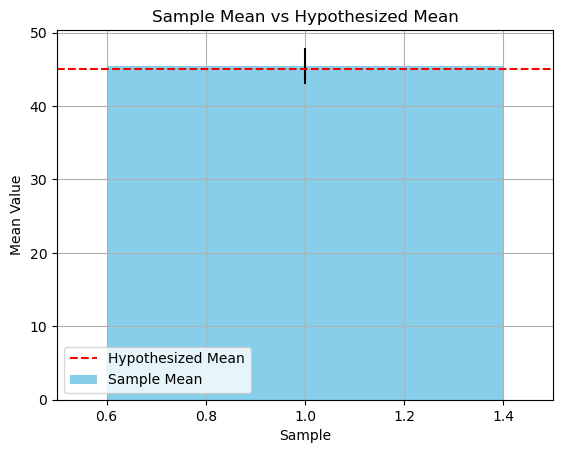

Interpretation: With a p-value of 0.5818 (> 0.05), there is no statistically significant evidence to reject the university's claim that students spend an average of 45 minutes on the experiment.


In [5]:
# Step 6: Visualize the data
plt.figure()
plt.bar(1, np.mean(data), color="skyblue", label='Sample Mean')
plt.errorbar(1, np.mean(data), yerr=np.std(data, ddof=1), fmt='k', linewidth=1.5)
plt.axhline(y=population_mean, color='r', linestyle='--', linewidth=1.5, label='Hypothesized Mean')
plt.title('Sample Mean vs Hypothesized Mean')
plt.xlim(0.5, 1.5)
plt.xlabel('Sample')
plt.ylabel('Mean Value')
plt.legend()
plt.grid(True)
plt.show()

print(f"Interpretation: With a p-value of {p_value:.4f} (> {alpha}), there is no statistically significant evidence to reject the university's claim that students spend an average of {population_mean} minutes on the experiment.")


---
# Question 2: Two-Sample t-Test

### Problem Statement:
An experiment compares the processing time of two algorithms. The measured processing times (in milliseconds) are:
* **Algorithm A:** `[42, 45, 39, 44, 41, 43, 40]`
* **Algorithm B:** `[48, 51, 46, 49, 50, 47, 52]`

Assume **equal population variances** and use **α = 0.05**.
Determine whether there is a significant difference between the average processing times of the two algorithms.

### Tasks:
1. State $H_0$ and $H_1$.
2. Calculate the sample means and sample variances ($ddof = 1$).
3. Calculate the mean difference between Algorithm A and Algorithm B.
4. Determine the pooled variance and standard error.
5. Calculate the t-statistic and degrees of freedom.
6. Find the two-tailed p-value.
7. Construct the 95% confidence interval for the mean difference.
8. Decision & Interpretation: State whether the evidence suggests that the two algorithms have different mean processing times.


## Task 1: State $H_0$ and $H_1$
* **Null Hypothesis ($H_0$):** $\mu_A = \mu_B$ (or $\mu_A - \mu_B = 0$)  
  *There is no significant difference between the average processing times of Algorithm A and Algorithm B.*
* **Alternative Hypothesis ($H_1$):** $\mu_A \neq \mu_B$ (or $\mu_A - \mu_B \neq 0$)  
  *There is a statistically significant difference between the average processing times of Algorithm A and Algorithm B.*
* **Significance Level:** $\alpha = 0.05$ (Two-tailed test, assuming equal population variances).


In [6]:
# Define the two independent datasets
data1 = np.array([42, 45, 39, 44, 41, 43, 40])  # Algorithm A
data2 = np.array([48, 51, 46, 49, 50, 47, 52])  # Algorithm B


## Task 2: Calculate the Sample Means and Sample Variances (ddof = 1)

In [7]:
# Sample sizes
n1, n2 = len(data1), len(data2)

# Sample means
mean1 = np.mean(data1)
mean2 = np.mean(data2)

# Sample variances (ddof=1 for sample variance with Bessel's correction)
s1_sq = np.var(data1, ddof=1)
s2_sq = np.var(data2, ddof=1)

print(f"Sample 1 (Algorithm A) Mean: {mean1:.2f} ms")
print(f"Sample 2 (Algorithm B) Mean: {mean2:.2f} ms")
print(f"Sample 1 (Algorithm A) Variance (ddof=1): {s1_sq:.4f}")
print(f"Sample 2 (Algorithm B) Variance (ddof=1): {s2_sq:.4f}")


Sample 1 (Algorithm A) Mean: 42.00 ms
Sample 2 (Algorithm B) Mean: 49.00 ms
Sample 1 (Algorithm A) Variance (ddof=1): 4.6667
Sample 2 (Algorithm B) Variance (ddof=1): 4.6667


## Task 3: Calculate the Mean Difference between Algorithm A and Algorithm B

In [8]:
# Mean difference
mean_diff = mean1 - mean2
print(f"Mean Difference (Algorithm A - Algorithm B): {mean_diff:.2f} ms")


Mean Difference (Algorithm A - Algorithm B): -7.00 ms


## Task 4: Determine the Pooled Variance and Standard Error

In [9]:
# Degrees of freedom
df = n1 + n2 - 2

# Pooled variance
sp_sq = ((n1 - 1) * s1_sq + (n2 - 1) * s2_sq) / (n1 + n2 - 2)

# Standard error using pooled variance
std_err = np.sqrt(sp_sq * (1/n1 + 1/n2))

print(f"Pooled Variance (sp^2): {sp_sq:.4f}")
print(f"Standard Error: {std_err:.4f}")


Pooled Variance (sp^2): 4.6667
Standard Error: 1.1547


## Task 5: Calculate the t-Statistic and Degrees of Freedom

In [10]:
# t-statistic (manual)
t_statistic = mean_diff / std_err

# Two-sample t-test verification using scipy.stats
t_statistic_scipy, p_value_scipy = stats.ttest_ind(data1, data2, equal_var=True)

print(f"t-Statistic: {t_statistic:.2f} (SciPy: {t_statistic_scipy:.2f})")
print(f"Degrees of Freedom: {df:.2f}")


t-Statistic: -6.06 (SciPy: -6.06)
Degrees of Freedom: 12.00


## Task 6: Find the Two-Tailed p-Value

In [11]:
# Two-tailed p-value
p_value = 2 * (1 - stats.t.cdf(abs(t_statistic), df))

print(f"p-Value: {p_value:.6f} (SciPy: {p_value_scipy:.6f})")


p-Value: 0.000057 (SciPy: 0.000057)


## Task 7: Construct the 95% Confidence Interval for the Mean Difference

In [12]:
# 95% confidence interval
ci = stats.t.interval(0.95, df, loc=mean_diff, scale=std_err)

print(f"95% Confidence Interval of Mean Difference: [{ci[0]:.2f}, {ci[1]:.2f}] ms")


95% Confidence Interval of Mean Difference: [-9.52, -4.48] ms


## Task 8: Decision & Interpretation

In [13]:
alpha = 0.05  # Significance level
if p_value < alpha:
    print(f"Decision: Reject the null hypothesis (H0) because p-value < alpha ({p_value:.6f} < {alpha}).")
    print("Interpretation: The evidence suggests that the two algorithms have significantly different mean processing times. Algorithm A is significantly faster than Algorithm B.")
else:
    print(f"Decision: Fail to reject the null hypothesis (H0) because p-value >= alpha ({p_value:.6f} >= {alpha}).")
    print("Interpretation: The evidence suggests that the two algorithms do not have significantly different mean processing times.")


Decision: Reject the null hypothesis (H0) because p-value < alpha (0.000057 < 0.05).
Interpretation: The evidence suggests that the two algorithms have significantly different mean processing times. Algorithm A is significantly faster than Algorithm B.


## Data Visualization: Comparison of Sample Means

Sample 1 Std: 2.1602
Sample 2 Std: 2.1602


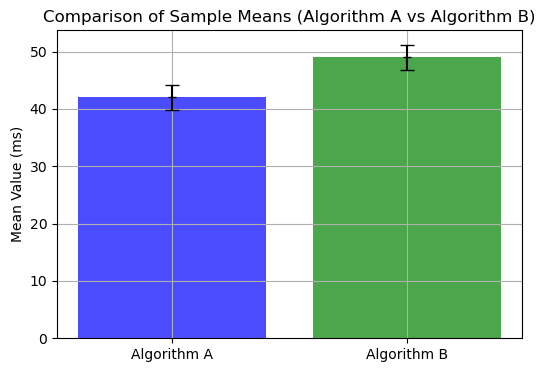

In [14]:
print(f"Sample 1 Std: {np.std(data1, ddof=1):.4f}")
print(f"Sample 2 Std: {np.std(data2, ddof=1):.4f}")

plt.figure(figsize=(6, 4))
plt.bar(['Algorithm A', 'Algorithm B'], [np.mean(data1), np.mean(data2)], color=['blue', 'green'], alpha=0.7)
plt.errorbar(['Algorithm A', 'Algorithm B'], [np.mean(data1), np.mean(data2)], yerr=[np.std(data1, ddof=1), np.std(data2, ddof=1)], fmt='k_', capsize=5)
plt.title('Comparison of Sample Means (Algorithm A vs Algorithm B)')
plt.ylabel('Mean Value (ms)')
plt.grid(True)
plt.show()
